In [1]:
import numpy as np 
import Physical_Const as phys
import WD_HT as WD

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,brentq
from scipy.integrate import ode, odeint


#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
sigma    = phys.sigmaSB
me_mev   = phys.me
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu
kappaB   = phys.kappa
Msun     = phys.Msun
Rsun     = phys.Rsun
pii      = np.pi

h        = hbar*(2.0*np.pi)
me       = me_mev * mevtoerg / c**2
c2       = c*c
arad     = 4.0*sigma / c
Tr       = me * c2 / kappaB
pi05     = np.sqrt(np.pi)
RBohr    = hbar**2 / (me*e_erg)
yr       = (364)*24*60*60
avo      = 1.0/mu


# ---Dimensions---
Sigma   = np.power(me,4.0)*np.power(c,3.0)/(8.0*np.power(pii,2.0)*np.power(hbar,3.0))
SigmaP  = c**2 * Sigma

MA      = 2.0
Sigma02 = (mu*MA*np.power(me*c/hbar,3))/(3*np.power(pii,2))
Rdim    = c/np.sqrt(Sigma02*G)
Cgrav   = G * Msun / c**2
Mdim    = Rdim / Cgrav


/home/laura/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
rhoEoS, xeEoS, PEoS, PsatEoS, chip_EoS = np.loadtxt("./C12_with_elec_energy.dat",usecols=(0,1,2,3,4),unpack=True)
rhoi  = np.log10( rhoEoS[0] )
rhof  = np.log10( rhoEoS[-1] )
xemin = xeEoS[0]
xemax = xeEoS[-1]
NN    = 100

# --- Degenerate electronic Pressure -----
def Pch_EoS(x):
    pWD = SigmaP*(x*np.sqrt(1.0+np.power(x,2.0))*(2.0*np.power(x,2.0)/3.0-1.0)+np.log(np.sqrt(1.0+np.power(x,2.0))+x))
    return pWD

def func(x, b):
    return ( np.power(10.0,rhof) / Sigma02 ) * np.power(x,b)/np.power(xemax,b)

#---find best fit-----
popt, pcov = curve_fit(func, xeEoS , rhoEoS / Sigma02)
afit = popt[0]

log_xXe = np.linspace(np.log10(xeEoS[0]*0.5),np.log10(xeEoS[-1]*1.5),NN)

xx_xe   = np.power(10.0,log_xXe)
EOS1    = np.zeros((2,NN))

#Create grid to fit fuction and calculate denrivatives EoS-------
for i in range(NN):
    xi = xx_xe[i]
    PP = Pch_EoS(xi)
    EOS1[0,i] = func(xi,afit)
    EOS1[1,i] = PP / ( c**2*Sigma02 )


DeDp_2 = []
DxeF   = 0.01
for i in range(NN):
    dx = xx_xe[i]*DxeF
    if i==0:
        Der = (func(xx_xe[i]+dx,afit) - EOS1[0][i]) / ( Pch_EoS(xx_xe[i]+dx) / (c**2*Sigma02) - EOS1[1][i])
    else:
        Der = (func(xx_xe[i]+dx,afit)-func(xx_xe[i]-dx,afit)) / (Pch_EoS(xx_xe[i]+dx)/(c**2*Sigma02)-Pch_EoS(xx_xe[i]-dx)/(c**2*Sigma02))
    DeDp_2.append(Der)

DeDpF       = interp1d(np.log10(EOS1[1]),  np.log10(DeDp_2),kind='cubic')
EoS_RFMT    = interp1d( EOS1[0], EOS1[1], kind='cubic' )
EoS_RFMT_02 = interp1d( EOS1[1], EOS1[0], kind = 'cubic')


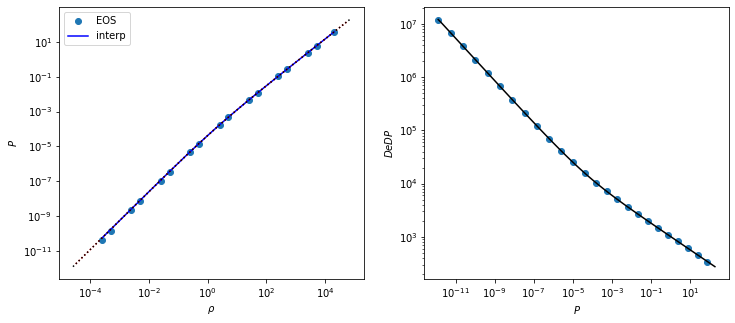

In [3]:
fig = plt.figure(figsize=(12,5))

plt.subplot(121)
x    = np.linspace(rhoi,rhof,100)
Pmin = np.log10(EOS1[1][1]); Pmax=np.log10(EOS1[1][-2])
xp   = np.linspace(Pmin,Pmax,100)

plt.loglog( rhoEoS/Sigma02, Pch_EoS(xeEoS)/ ( c**2*Sigma02 ),'o', label="EOS")

plt.loglog( np.power(10,x)/Sigma02, EoS_RFMT(np.power(10,x)/Sigma02), 'b-', label="interp")
plt.loglog( EoS_RFMT_02(np.power(10,xp)), np.power(10,xp) ,'r:')
plt.loglog( EOS1[0], EOS1[1],'k:')

plt.legend()

plt.xlabel("$\\rho$")
plt.ylabel("$P$")

plt.subplot(122)
#---Plot derivative EoS-----
Pmin = np.log10(EOS1[1][0]) 
Pmax = np.log10(EOS1[1][-1])
x    = np.linspace(Pmin,Pmax,100)

plt.loglog(EOS1[1][::4],DeDp_2[::4],'o')
plt.loglog(np.power(10,x),np.power(10,DeDpF(x)),'k-')

plt.xlabel("$P$")
plt.ylabel("$DeDP$")

plt.show()


In [4]:
dr = 1e-4
rf = 1.0

Nm    = 10
rhoc  = np.linspace(rhoi*1.7,rhof,Nm)
rhons = np.power(10.0,rhoc)/Sigma02
pc    = EoS_RFMT( rhons )

MR_WD = np.zeros((Nm, 2))
JO_WD = np.zeros((Nm, 2))

for i in range(Nm):
    #m00    = ( 4.0 / 3.0 ) * np.pi * (dr)**3 * rhons[i]
    #Pi     = pc[i] - (  2.0*np.pi*( pc[i] + rhons[i] )*( pc[i] + rhons[i]/3.0 ) )*dr**2
    #nuc    = 4.0*np.pi*(  pc[i] + rhons[i]/3.0 )*dr**2
    #ooc    = 1.0
    #omegac = ooc + (8.0*np.pi/3.0)*( pc[i] + rhons[i] )* ooc * dr**2
    #Domegac = (16.0*np.pi/3.0) * ( pc[i] + rhons[i]) * ooc * dr

    y0i = WD.IntCond_Static( rhons[i], pc[i], dr )
    WD_s  = WD.StaticSeq( y0i , dr, rf, EOS1 )
    #WD_s = WD.StaticSeq( [m00, Pi, nuc, Domegac, omegac ] , dr, rf, EOS1 )
    MR_WD[i,0] = WD_s[0]
    MR_WD[i,1] = WD_s[1]

    JO_WD[i,0] = WD_s[3]
    JO_WD[i,1] = WD_s[4]
    

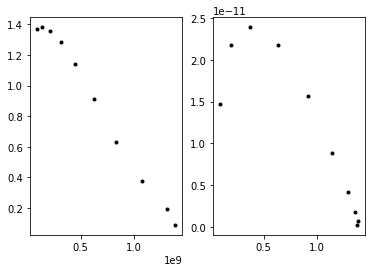

In [5]:
plt.subplot(121)
plt.plot( MR_WD[:,1]*Rdim , MR_WD[:, 0]*Mdim , "k.")

plt.subplot(122)
plt.plot( MR_WD[:,0]*Mdim , JO_WD[:, 0]/JO_WD[:, 1], "k.")

In [6]:
dr = 1e-4
rf = 1.0
pi4 = 4.0 * np.pi
OmegaS = 1.2

Nm    = 10
rhoc  = np.linspace(rhoi*1.8,rhof,Nm)
rhons = np.power(10.0,rhoc)/Sigma02
pc    = EoS_RFMT( rhons )

MR_WD = np.zeros((Nm, 8))

for i in range(Nm):

    y0i = WD.IntCond_Static( rhons[i], pc[i], dr )
    MS  = WD.StaticSeq( y0i , dr, rf, EOS1 )
        
    dedp0 = DeDpF( np.log10( pc[i] ) ) 
    y0i   = WD.IntCond_Rotating( OmegaS, MS[4], rhons[i], pc[i], MS[2], dr , rf , EOS1, dedp0 )
   
    #Integrate Equations
    MR_WD[i] = WD.MassRadius(y0i, dr, rf,  EOS1, DeDp_2 )

(0.0, 2.0)

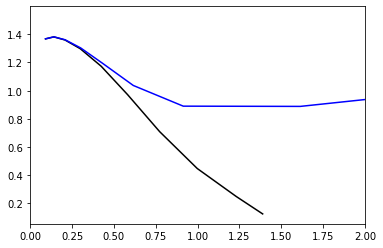

In [7]:
plt.plot( 1e-9*MR_WD[:,1]*Rdim , MR_WD[:, 0]*Mdim , "k-")
plt.plot( 1e-9*MR_WD[:,7]*Rdim , MR_WD[:, 6]*Mdim , "b-")

plt.xlim(0.0,2)

In [8]:
dr = 1e-4
rf = 1.0

Nm    = 10
rhocc  = np.linspace(rhoi*1.8, rhof,Nm)
rhons = np.power(10.0,rhocc)/Sigma02
pc    = EoS_RFMT( rhons )

MR_kep = np.zeros((Nm, 8))

for i in range(Nm):
    
    dedp0 = DeDpF( np.log10( pc[i] ) )
    y0i = WD.IntCond_Static( rhons[i], pc[i], dr )
    
    MS  = WD.StaticSeq( y0i , dr, rf, EOS1 )
        
    OK  = WD.OmegaK( MS[0], MS[1], 0, 0 , 0 )
    
    y0i = WD.IntCond_Rotating( OK, MS[4], rhons[i], pc[i], MS[2], dr , rf , EOS1, dedp0 )   
    MR  = WD.MassRadius(y0i, dr, rf,  EOS1, DeDp_2 )

    OK  = WD.OmegaK( MR[6] , MR[1] , MR[6]-MR[0],  MR[3] / MR[0]**2.0, MR[5] / MR[0]**3.0 )
    cut=0
    while np.abs(MR[4]-OK)>1e-3 and cut<80:
        y0i = WD.IntCond_Rotating( OK, MS[4], rhons[i], pc[i], MS[2], dr , rf , EOS1, dedp0 )   
        MR  = WD.MassRadius(y0i, dr, rf,  EOS1, DeDp_2 )
        OK  = WD.OmegaK( MR[6] , MR[1] , MR[6]-MR[0],  MR[3] / MR[0]**2.0, MR[5] / MR[0]**3.0 )
        cut += 1
    
    MR_kep[i] = MR
    
    

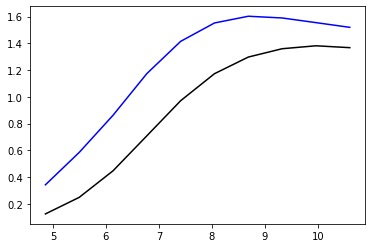

In [9]:
plt.plot( rhocc ,  MR_kep[:, 0]*Mdim , "k-")
plt.plot( rhocc ,   MR_kep[:, 6]*Mdim , "b-")

#plt.xlim(0.0,2)

In [10]:
rhocc

array([ 4.85915067,  5.49689803,  6.13464539,  6.77239275,  7.41014011,
        8.04788747,  8.68563484,  9.3233822 ,  9.96112956, 10.59887692])

In [11]:
MR_kep

array([[ 2.21834123e-07,  1.67000000e-02, -3.47845938e-16,
         8.68347787e-12,  4.72482034e-01,  3.39923641e-16,
         6.06235842e-07,  3.32338838e-02],
       [ 4.40666255e-07,  1.48000000e-02, -2.46145742e-15,
         1.66816209e-11,  7.26090666e-01,  6.31627233e-16,
         1.03440577e-06,  2.62195021e-02],
       [ 7.91511284e-07,  1.20000000e-02, -1.70951306e-14,
         2.76719977e-11,  1.16451461e+00,  9.68232938e-16,
         1.52511160e-06,  1.89714210e-02],
       [ 1.25371074e-06,  9.30000000e-03, -7.82690427e-14,
         3.92209443e-11,  1.92345692e+00,  1.23013203e-15,
         2.07540671e-06,  1.36566220e-02],
       [ 1.71732559e-06,  7.00000000e-03, -3.56014217e-09,
         4.38297059e-11,  3.12264184e+00,  1.12665458e-15,
         2.50123149e-06,  9.74717709e-03],
       [ 2.07410111e-06,  5.10000000e-03, -1.48346351e-09,
         4.01705948e-11,  5.10216670e+00,  7.91366276e-16,
         2.74382167e-06,  6.86839541e-03],
       [ 2.29363544e-06,  3.600000